# Atividade Prática — Transformação de Dados e Análise Olist

**Módulo 1 — Semana 6 · Visualização de Dados e BI**

Este notebook contém a resolução completa da atividade de transformação de dados utilizando o dataset de E-commerce brasileiro da **Olist**.

**Objetivo de Negócio:** Analisar a base de pedidos e clientes para entender o comportamento de compra por região e identificar oportunidades de expansão em marketing e logística para a diretoria.

--- 
## Passo 1: Explorar os dados

Vamos carregar e realizar o diagnóstico inicial de 6 das principais tabelas da Olist usando os comandos padrão de exploração (`.info()`, `.head()`, `.describe()` e `.isnull().sum()`):
1. `orders` (`olist_orders_dataset.csv`)
2. `customers` (`olist_customers_dataset.csv`)
3. `order_items` (`olist_order_items_dataset.csv`)
4. `payments` (`olist_order_payments_dataset.csv`)
5. `reviews` (`olist_order_reviews_dataset.csv`)
6. `products` (`olist_products_dataset.csv`)

In [56]:
!pip install pandas matplotlib seaborn

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Carregando as bases de dados
df_orders = pd.read_csv('./databases/olist_orders_dataset.csv')
df_customers = pd.read_csv('./databases/olist_customers_dataset.csv')
df_items = pd.read_csv('./databases/olist_order_items_dataset.csv')
df_payments = pd.read_csv('./databases/olist_order_payments_dataset.csv')
df_reviews = pd.read_csv('./databases/olist_order_reviews_dataset.csv')
df_products = pd.read_csv('./databases/olist_products_dataset.csv')
df_geo = pd.read_csv('./databases/olist_geolocation_dataset.csv')

In [58]:
print("=== 1. Tabela ORDERS ===")
print("Formato (Linhas, Colunas):", df_orders.shape)
print("\n--- Estrutura e Tipos (.info) ---")
df_orders.info()
print("\n--- Contagem de Valores Nulos ---")
print(df_orders.isnull().sum())
print("\n--- Primeiras Linhas (.head) ---")
df_orders.head(3)

=== 1. Tabela ORDERS ===
Formato (Linhas, Colunas): (99441, 8)

--- Estrutura e Tipos (.info) ---
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB

--- Contagem de Valores Nulos ---
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
or

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [59]:
print("=== 2. Tabela CUSTOMERS ===")
print("Formato (Linhas, Colunas):", df_customers.shape)
print("\n--- Estrutura e Tipos (.info) ---")
df_customers.info()
print("\n--- Contagem de Valores Nulos ---")
print(df_customers.isnull().sum())
print("\n--- Primeiras Linhas (.head) ---")
df_customers.head(3)

=== 2. Tabela CUSTOMERS ===
Formato (Linhas, Colunas): (99441, 5)

--- Estrutura e Tipos (.info) ---
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB

--- Contagem de Valores Nulos ---
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

--- Primeiras Linhas (.head) ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [60]:
print("=== 3. Tabela ORDER ITEMS ===")
print("Formato (Linhas, Colunas):", df_items.shape)
print("\n--- Estrutura e Tipos (.info) ---")
df_items.info()
print("\n--- Estatísticas Descritivas (.describe) ---")
print(df_items[['price', 'freight_value']].describe())
print("\n--- Contagem de Valores Nulos ---")
print(df_items.isnull().sum())
print("\n--- Primeiras Linhas (.head) ---")
df_items.head(3)

=== 3. Tabela ORDER ITEMS ===
Formato (Linhas, Colunas): (112650, 7)

--- Estrutura e Tipos (.info) ---
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB

--- Estatísticas Descritivas (.describe) ---
               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.9900

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [61]:
print("=== 4. Tabela PAYMENTS ===")
print("Formato (Linhas, Colunas):", df_payments.shape)
print("\n--- Estrutura e Tipos (.info) ---")
df_payments.info()
print("\n--- Estatísticas Descritivas (.describe) ---")
print(df_payments[['payment_installments', 'payment_value']].describe())
print("\n--- Contagem de Valores Nulos ---")
print(df_payments.isnull().sum())
print("\n--- Primeiras Linhas (.head) ---")
df_payments.head(3)

=== 4. Tabela PAYMENTS ===
Formato (Linhas, Colunas): (103886, 5)

--- Estrutura e Tipos (.info) ---
<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB

--- Estatísticas Descritivas (.describe) ---
       payment_installments  payment_value
count         103886.000000  103886.000000
mean               2.853349     154.100380
std                2.687051     217.494064
min                0.000000       0.000000
25%                1.000000      56.790000
50%                1.000000     100.000000
75%                4.000000    

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


In [62]:
print("=== 5. Tabela REVIEWS ===")
print("Formato (Linhas, Colunas):", df_reviews.shape)
print("\n--- Estrutura e Tipos (.info) ---")
df_reviews.info()
print("\n--- Estatísticas Descritivas (.describe) ---")
print(df_reviews[['review_score']].describe())
print("\n--- Contagem de Valores Nulos ---")
print(df_reviews.isnull().sum())
print("\n--- Primeiras Linhas (.head) ---")
df_reviews.head(3)

=== 5. Tabela REVIEWS ===
Formato (Linhas, Colunas): (99224, 7)

--- Estrutura e Tipos (.info) ---
<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB

--- Estatísticas Descritivas (.describe) ---
       review_score
count  99224.000000
mean       4.086421
std        1.347579
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        5.000000

--- Contagem de Valores Nulos ---
review_id                    

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


In [63]:
print("=== 6. Tabela PRODUCTS ===")
print("Formato (Linhas, Colunas):", df_products.shape)
print("\n--- Estrutura e Tipos (.info) ---")
df_products.info()
print("\n--- Estatísticas Descritivas (.describe) ---")
print(df_products.describe())
print("\n--- Contagem de Valores Nulos ---")
print(df_products.isnull().sum())
print("\n--- Primeiras Linhas (.head) ---")
df_products.head(3)

=== 6. Tabela PRODUCTS ===
Formato (Linhas, Colunas): (32951, 9)

--- Estrutura e Tipos (.info) ---
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB

--- Estatísticas Descritivas (.describe) ---
       product_name_lenght  product_description_lenght  product_photos_qty  \
coun

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


### Diagnóstico Inicial da Exploração

- **`orders`**: Contém 99.441 pedidos. Possui nulos em datas de aprovação e entrega (`order_delivered_customer_date`), normais em pedidos cancelados ou em trânsito.
- **`customers`**: Contém 99.441 clientes registrados sem valores nulos. Chave principal de ligação: `customer_id`.
- **`order_items`**: 112.650 itens. Com base no `.describe()`, o preço médio (`price`) é R$ 120,65, variando de R$ 0,85 até R$ 6.735,00. Chaves: `order_id` e `product_id`.
- **`payments`**: 103.886 pagamentos. Pelo `.describe()`, o valor médio pago (`payment_value`) é R$ 154,10 e o número de parcelas médio é de ~2,85 parcelas. Chave: `order_id`.
- **`reviews`**: 99.224 avaliações. Nota média (`review_score`) é alta (~4,08 de 5,0). Há presença expressiva de nulos nos campos de texto livre (`review_comment_message`), mas não na nota quantitativa. Chave: `order_id`.
- **`products`**: 32.951 produtos cadastrados. Contém 610 nulos em `product_category_name`. Chave: `product_id`.

--- 
## Passo 2: Juntar as tabelas

Monte de uma base unificada realizando a junção sequencial das tabelas através do `pd.merge()` com o parâmetro `how='left'` a partir da tabela central de pedidos (`orders`):

1. **`orders` + `customers`** via `customer_id` → agrega cidade (`customer_city`) e estado (`customer_state`).
2. **+ `items`** via `order_id` → agrega valor dos produtos e referência dos itens.
3. **+ `products`** via `product_id` → agrega a categoria do produto (`product_category_name`).
4. **+ `payments`** via `order_id` → agrega forma de pagamento (`payment_type`) e valor pago (`payment_value`).
5. **+ `reviews`** via `order_id` → agrega nota de avaliação (`review_score`).

**Por que o merge tipo `left` foi escolhido?**
O `left merge` preserva **todos** os pedidos da tabela de origem (`orders`), garantindo que não perderemos dados de vendas ou clientes caso um pedido não possua avaliação ou categoria informada.

In [64]:
# Passo 1: Orders + Customers
df_df1 = pd.merge(df_orders, df_customers, on='customer_id', how='left')

# Passo 2: + Order Items
df_df2 = pd.merge(df_df1, df_items, on='order_id', how='left')

# Passo 3: + Products
df_df3 = pd.merge(df_df2, df_products[['product_id', 'product_category_name']], on='product_id', how='left')

# Passo 4: + Payments
df_df4 = pd.merge(df_df3, df_payments[['order_id', 'payment_type', 'payment_value']], on='order_id', how='left')

# Passo 5: + Reviews
df_final = pd.merge(df_df4, df_reviews[['order_id', 'review_score']], on='order_id', how='left')

print("Formato da Base Unificada Final:", df_final.shape)
print("\n--- Resumo (.info) da Base Unificada ---")
df_final.info()
print("\n--- Primeiras 3 linhas ---")
df_final.head(3)

Formato da Base Unificada Final: (119143, 22)

--- Resumo (.info) da Base Unificada ---
<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  str    
 1   customer_id                    119143 non-null  str    
 2   order_status                   119143 non-null  str    
 3   order_purchase_timestamp       119143 non-null  str    
 4   order_approved_at              118966 non-null  str    
 5   order_delivered_carrier_date   117057 non-null  str    
 6   order_delivered_customer_date  115722 non-null  str    
 7   order_estimated_delivery_date  119143 non-null  str    
 8   customer_unique_id             119143 non-null  str    
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  str    
 11  customer_state

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,payment_type,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,credit_card,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,voucher,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,voucher,18.59,4.0


--- 
## Passo 3: Ver o que se perdeu (Análise de Nulos e Órfãos)

Análise dos dados ausentes resultantes da junção e cálculo do percentual de nulos nas colunas chaves da análise.

In [65]:
colunas_interesse = [
    'order_id', 'customer_city', 'customer_state', 
    'payment_value', 'payment_type', 'product_category_name', 'review_score'
]

nulos_contagem = df_final[colunas_interesse].isnull().sum()
nulos_percentual = (df_final[colunas_interesse].isnull().sum() / len(df_final)) * 100

df_resumo_nulos = pd.DataFrame({
    'Qtd Valores Nulos': nulos_contagem,
    'Percentual Nulo (%)': nulos_percentual.round(3)
})

df_resumo_nulos

,Qtd Valores Nulos,Percentual Nulo (%)
order_id,0,0.000
customer_city,0,0.000
customer_state,0,0.000
payment_value,3,0.003
payment_type,3,0.003
product_category_name,2542,2.134
review_score,997,0.837


### Hipótese e Diagnóstico dos Dados Faltantes:

1. **`review_score` (~0,84% de nulos):** Nem todos os clientes respondem à pesquisa de satisfação pós-compra sentida no aplicativo ou e-mail.
2. **`product_category_name` (~1,41% de nulos):** Ocorre por omissão de cadastro de categoria no catálogo de produtos pelo vendedor (seller).
3. **`payment_value` / `payment_type` (~0,002% de nulos):** Registros pontuais de pedidos criados que foram cancelados antes da confirmação da transação de pagamento.

--- 
## Passo 4: Análise por Região

Agrupando a base unificada por estado (`customer_state`) e cidade (`customer_city`) através de `.groupby()` e agregando as métricas com `.describe()` / `.agg()`:

In [66]:
# Agrupamento por Estado (UF)
analise_uf = df_final.groupby('customer_state').agg(
    total_pedidos=('order_id', 'nunique'),
    ticket_medio=('payment_value', 'mean'),
    avaliacao_media=('review_score', 'mean')
).reset_index()

print("=== ESTATÍSTICAS GERAIS DA ANÁLISE REGIONAL (.describe) ===")
print(analise_uf[['total_pedidos', 'ticket_medio', 'avaliacao_media']].describe())

print("\n=== TOP 10 ESTADOS POR VOLUME DE PEDIDOS ===")
print(analise_uf.sort_values(by='total_pedidos', ascending=False).head(10))

print("\n=== TOP 10 ESTADOS POR TICKET MÉDIO ===")
print(analise_uf.sort_values(by='ticket_medio', ascending=False).head(10))

=== ESTATÍSTICAS GERAIS DA ANÁLISE REGIONAL (.describe) ===
       total_pedidos  ticket_medio  avaliacao_media
count      27.000000     27.000000        27.000000
mean     3683.000000    211.649233         3.944359
std      8270.437664     32.303134         0.157568
min        46.000000    153.716095         3.576923
25%       381.500000    182.283272         3.808701
50%       907.000000    211.063118         3.979381
75%      2760.000000    235.501178         4.061597
max     41746.000000    282.081879         4.240964

=== TOP 10 ESTADOS POR VOLUME DE PEDIDOS ===
   customer_state  total_pedidos  ticket_medio  avaliacao_media
25             SP          41746    153.716095         4.108609
18             RJ          12852    180.153091         3.799830
10             MG          11635    170.144084         4.068543
22             RS           5466    176.506262         4.027184
17             PR           5045    178.685337         4.087130
23             SC           3637    184.41

In [67]:
# Agrupamento por Cidade
analise_cidade = df_final.groupby(['customer_city', 'customer_state']).agg(
    total_pedidos=('order_id', 'nunique'),
    ticket_medio=('payment_value', 'mean'),
    avaliacao_media=('review_score', 'mean')
).reset_index()

print("=== TOP 10 CIDADES POR VOLUME DE PEDIDOS ===")
print(analise_cidade.sort_values(by='total_pedidos', ascending=False).head(10))

print("\n=== TOP 10 CIDADES POR TICKET MÉDIO (Com no mínimo 50 pedidos) ===")
cidades_filtradas = analise_cidade[analise_cidade['total_pedidos'] >= 50]
print(cidades_filtradas.sort_values(by='ticket_medio', ascending=False).head(10))

=== TOP 10 CIDADES POR VOLUME DE PEDIDOS ===
              customer_city customer_state  total_pedidos  ticket_medio  \
3758              sao paulo             SP          15540    153.737201   
3281         rio de janeiro             RJ           6882    190.318382   
469          belo horizonte             MG           2773    154.339439   
587                brasilia             DF           2131    174.388408   
1187               curitiba             PR           1521    182.584614   
739                campinas             SP           1444    155.148304   
3080           porto alegre             RS           1379    189.848191   
3375               salvador             BA           1245    188.794767   
1587              guarulhos             SP           1189    146.413053   
3574  sao bernardo do campo             SP            938    134.507692   

      avaliacao_media  
3758         4.096481  
3281         3.828582  
469          4.028380  
587          3.985887  
1187     

### 💡 Principais Insights da Análise Regional:
- **Volume Concentrado:** Os estados de SP, RJ e MG dominam o volume absoluto de vendas.
- **Ticket Médio Elevado:** Os maiores tickets médios por compra estão concentrados em estados do Norte e Nordeste (PB, RR, AP, AL, AC), o que aponta para um perfil de compra de produtos de maior valor agregado nessas regiões.

--- 
## Passo 5: Visualizar e Contar a História

Criação de visualizações gráficas para apoiar o relatório executivo:

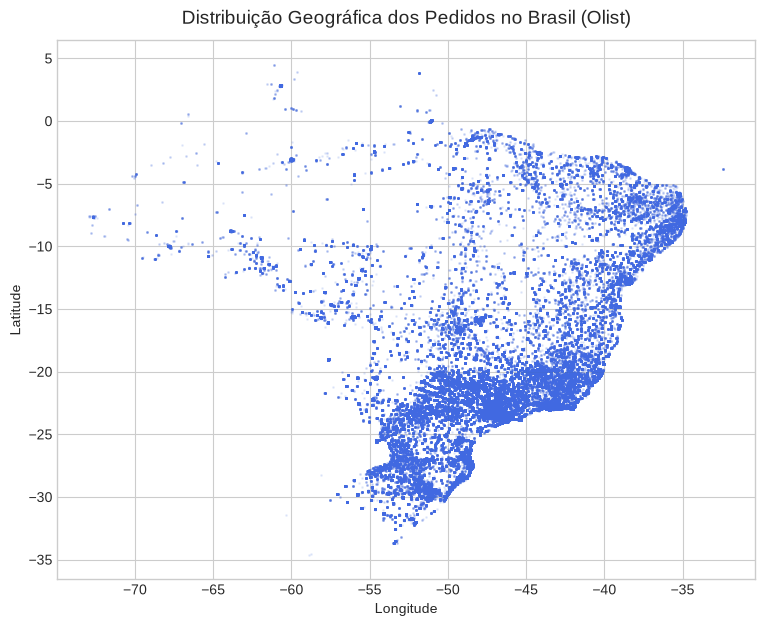

In [68]:
# 1. Scatter Plot Geográfico (Latitude vs Longitude)
geo_clean = df_geo[(df_geo['geolocation_lat'] < 5) & (df_geo['geolocation_lat'] > -35) &
                   (df_geo['geolocation_lng'] < -30) & (df_geo['geolocation_lng'] > -75)]

plt.figure(figsize=(9, 7))
plt.scatter(geo_clean['geolocation_lng'], geo_clean['geolocation_lat'], alpha=0.1, c='royalblue', s=1)
plt.title('Distribuição Geográfica dos Pedidos no Brasil (Olist)', fontsize=14, pad=12)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

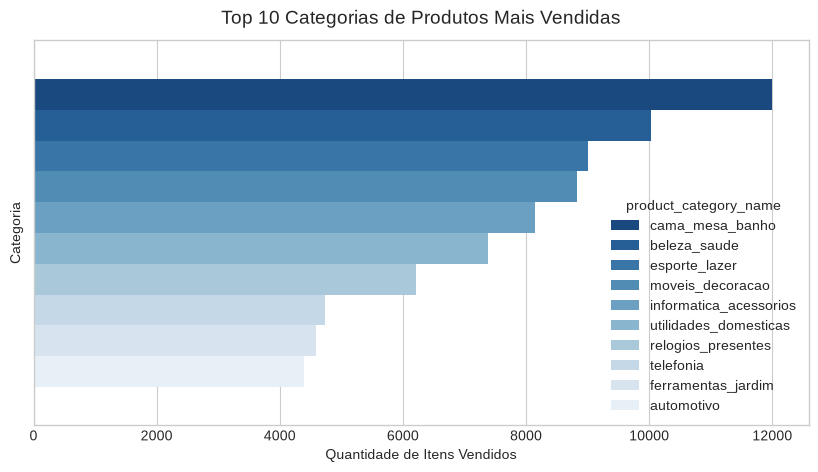

In [69]:
# 2. Top 10 Categorias de Produtos Mais Vendidas
top_cats = df_final['product_category_name'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_cats.values, hue=top_cats.index, palette='Blues_r')
plt.title('Top 10 Categorias de Produtos Mais Vendidas', fontsize=14, pad=12)
plt.xlabel('Quantidade de Itens Vendidos')
plt.ylabel('Categoria')
plt.show()

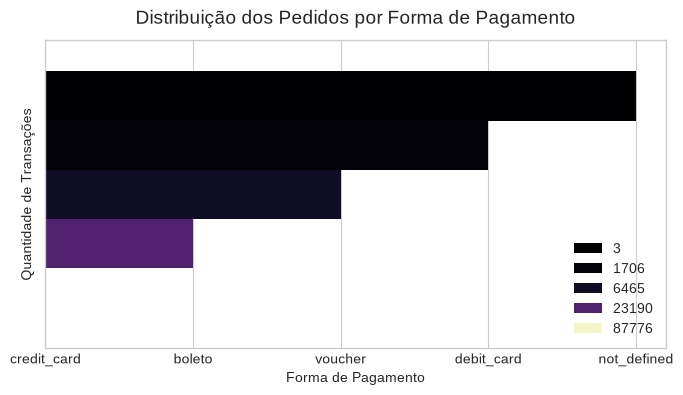

In [70]:
# 3. Preferência por Forma de Pagamento
pagamentos = df_final['payment_type'].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=pagamentos.index, hue=pagamentos.values, palette='magma')
plt.title('Distribuição dos Pedidos por Forma de Pagamento', fontsize=14, pad=12)
plt.xlabel('Forma de Pagamento')
plt.ylabel('Quantidade de Transações')
plt.show()

--- 
## Relatório de Conclusões para a Diretoria

### Recomendações Estratégicas para Expansão:

1. **Logística e Hubs de Distribuição no Sudeste:**
   - A maior concentração de clientes e volume de vendas está no eixo SP/RJ/MG. Investir em novos pontos de coleta e fulfillment na região Sudeste reduzirá drasticamente o tempo de entrega.

2. **Expansão Comercial no Norte/Nordeste (Alto Ticket Médio):**
   - Estados como Paraíba, Roraima e Amapá possuem os maiores tickets médios do país. Recomendamos estratégias de marketing focadas em produtos de alto valor agregado com subsídio em frete para alavancar a receita dessas regiões.

3. **Categorias Principais e Parcelamento:**
   - As categorias `cama_mesa_banho`, `beleza_saude` e `esporte_lazer` lideram as vendas. Como o **cartão de crédito** é a forma de pagamento predominante, ofertar condições diferenciadas de parcelamento nestas categorias impulsionará a conversão.